<a href="https://colab.research.google.com/github/Alilson2/Projeto_IA/blob/main/Projeto_Modelo_Regress%C3%A3o_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr # Ler arquivos netcdf
from google.colab import drive
import seaborn as sns

!pip install cartopy
import cartopy

import cartopy.crs as ccrs # Escolha do sistema de coordenadas
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import matplotlib.patches as mpatches # Desenhar geometria em um mapa

from scipy.stats import gamma, norm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 65.7 MB/s eta 0:00:00


In [2]:
import os
import xarray as xr

# --- Clonar repositório se não existir ---
if not os.path.exists("Projeto_IA"):
    !git clone https://github.com/Alilson2/Projeto_IA.git
else:
    print("📁 Repositório 'Projeto_IA' já existe — pulando o clone.")

# --- Verificar se a pasta foi criada ---
if not os.path.exists("Projeto_IA"):
    raise FileNotFoundError("❌ A pasta 'Projeto_IA' não foi encontrada. O clone pode ter falhado.")
else:
    print("\n✅ Repositório clonado com sucesso!\n")
    print("Arquivos dentro da pasta Projeto_IA:\n", os.listdir("Projeto_IA"))

# --- Localizar arquivos .nc ---
arquivos_nc = [f for f in os.listdir("Projeto_IA") if f.endswith(".nc")]
if not arquivos_nc:
    raise FileNotFoundError("❌ Nenhum arquivo .nc encontrado na pasta Projeto_IA!")
else:
    print("\n📂 Arquivo(s) NetCDF encontrado(s):")
    for f in arquivos_nc:
        print(" -", f)

# --- Montar lista de caminhos ---
ARQUIVO = [os.path.join("Projeto_IA", f) for f in arquivos_nc]

# --- Função para corrigir longitude ---
def corrigir_longitude(ds):
    for coord in ["longitude", "lon"]:
        if coord in ds.coords:
            ds = ds.assign_coords({coord: ((ds[coord] + 180) % 360) - 180})
            ds = ds.sortby(coord)
    return ds

# --- Abrir arquivos com segurança (nova sintaxe) ---
try:
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='by_coords',
        parallel=True,           # usa múltiplos núcleos
        preprocess=corrigir_longitude,
        combine_attrs='override' # 🟢 substitui o antigo compat='override'
    )
except ValueError as e:
    print("\n⚠️ Erro na combinação — tentando modo 'nested' (concat por tempo)...")
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='nested',
        concat_dim='valid_time',  # ajuste se sua dimensão temporal tiver outro nome
        parallel=True,
        preprocess=corrigir_longitude,
        combine_attrs='override'
    )

print("\n✅ Dataset carregado com sucesso!\n")
dados

Cloning into 'Projeto_IA'...
remote: Enumerating objects: 284, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 284 (delta 58), reused 24 (delta 24), pack-reused 205 (from 1)
Receiving objects: 100% (284/284), 166.28 MiB | 40.71 MiB/s, done.
Resolving deltas: 100% (82/82), done.

✅ Repositório clonado com sucesso!

Arquivos dentro da pasta Projeto_IA:
 ['(JAN 2024 - 16a31) ea884d573d8753c6f2976f9e4b642c11.nc', '(ABR 2020-1 a 24).nc', '(OUT 2020-1 a 24).nc', '(SET 2020-1 a 24).nc', 'Projeto_IA_Arima_regressao.ipynb', '(DEZEMBRO 2024 - 16a31) 39b3910eee1ef3c1aaa6ca43cba3f9a5.nc', 'SET 2022 - 16a30.nc', '(Junho 2021-16 a 30).nc', '(SET 2020-25 a 30).nc', '(MAIO 2023 - 16a31) c5f19b02b4981b080ef04ca83a2585da.nc', '(JUN 2020-1 a 24).nc', 'AGO 2022 - 16a31.nc', '(DEZEMBRO 2023 - 1a15).nc', '(OUTUBRO 2024 - 16a31) b3f505f9374108f770a431d1f104a163.nc', '(MAIO 2021-16 a 30).nc', '(SETEMBRO 2023 - 16a30).nc', '(DEZEMBRO 2023 - 16a

/tmp/ipython-input-2195183609.py:39: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-2195183609.py:39: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(



⚠️ Erro na combinação — tentando modo 'nested' (concat por tempo)...


/tmp/ipython-input-2195183609.py:48: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-2195183609.py:48: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(



✅ Dataset carregado com sucesso!



<xarray.Dataset> Size: 464MB
Dimensions:     (valid_time: 43848, latitude: 12, longitude: 22)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2024-01-16 ... 2023-04-30T2...
  * latitude    (latitude) float64 96B -24.2 -24.2 -24.1 ... -23.4 -23.3 -23.2
  * longitude   (longitude) float64 176B -47.2 -47.19 -47.1 ... -46.2 -46.19
    number      int64 8B 0
    expver      (valid_time) <U4 702kB dask.array<chunksize=(384,), meta=np.ndarray>
Data variables:
    d2m         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    slhf        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    sshf        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    ssrd        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    e           (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    sp          (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(384, 11, 11), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-24T19:46 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
df = dados.to_dataframe()
df = df.dropna()

# --- 2️⃣ Verificar se há a coordenada temporal ---
if "valid_time" not in dados.coords:
    raise ValueError("❌ O dataset não contém uma coordenada temporal chamada 'valid_time'.")

# --- 3️⃣ Converter o eixo temporal para pandas.DatetimeIndex ---
tempo = pd.to_datetime(dados["valid_time"].values)

# --- 4️⃣ Criar DataFrame com componentes temporais ---
df_tempo = pd.DataFrame({
    "timestamp": tempo,
    "timestamp_segundos": tempo.view("int64"),   # segundos desde 1970
    "ano": tempo.year,
    "mes": tempo.month,
    "dia": tempo.day,
    "hora": tempo.hour,
    "minuto": tempo.minute,
    "segundo": tempo.second,
    "dia_semana": tempo.dayofweek,
    "dia_do_ano": tempo.dayofyear
})

#print(df_tempo.head())

# Exemplo: seleciona uma variável e um período
# Sort the dataset by valid_time before slicing
dados_sorted = dados.sortby('valid_time')
dados_filtrado = dados_sorted

# Converte para pandas sem estourar RAM
df_panda = dados_filtrado.to_dataframe().reset_index()
df_panda = df_panda.dropna()

# Junta com df_tempo
df_final = pd.merge(
    df_panda,
    df_tempo,
    left_on='valid_time',
    right_on='timestamp',
    how='left'
)


df_final['longitude'] = np.round(df_final['longitude'], 1)
df_final['latitude'] = np.round(df_final['latitude'], 1)

In [4]:
# ============================================================
# 1) Seleção de coordenadas
# ============================================================

def selecionar_coordenadas(df, N_lim, S_lim, L_lim, O_lim):

    df = df[
        (df["latitude"] <= N_lim) &
        (df["latitude"] >= S_lim) &
        (df["longitude"] >= O_lim) &
        (df["longitude"] <= L_lim)
    ]

    df = df.drop_duplicates(subset=["valid_time", "latitude", "longitude"])
    return df



# ============================================================
# 2) Cálculo de vapor, RH e VPD
# ============================================================

def calcula_vapor_umidade(df):

    t2m_c = df["t2m"] - 273.15
    d2m_c = df["d2m"] - 273.15

    es = 610.94 * np.exp(17.625 * t2m_c / (243.04 + t2m_c))
    ev = 610.94 * np.exp(17.625 * d2m_c / (243.04 + d2m_c))

    df["es"]  = es
    df["ev"]  = ev
    df["RH"]  = 100 * ev / es
    df["VPD"] = (es - ev) / 1000

    return df



# ============================================================
# 3) Agregar por dia e por pixel (SEM STD)
# ============================================================

def criar_dados(df):

    df["data"] = pd.to_datetime(df["valid_time"]).dt.date

    # Variáveis com estatísticas: mean, min, max
    vars_stats = ['d2m', 't2m', 'u10', 'v10', 'sp', 'es', 'ev', 'RH', 'VPD']

    # Variáveis que usam somente o último valor do dia
    vars_last = ["e", "ssrd", "sshf", "slhf", "tp"]

    g = df.groupby(["data", "latitude", "longitude"])

    resultados = {}

    # ---------- Estatísticas ----------
    for var in vars_stats:
        resultados[f"{var}_mean"] = g[var].mean()
        resultados[f"{var}_min"]  = g[var].min()
        resultados[f"{var}_max"]  = g[var].max()

    # ---------- Último valor ----------
    for var in vars_last:
        resultados[f"{var}_last"] = g[var].last()

    df_pixel = pd.concat(resultados, axis=1).reset_index()
    return df_pixel



# ============================================================
# 4) Agregar regionalmente (AQUI sim tem STD)
# ============================================================

def agregar_regional(df_pixel):

    df_pixel["data"] = pd.to_datetime(df_pixel["data"])
    df_pixel["mes"]  = df_pixel["data"].dt.month

    g = df_pixel.groupby("data")
    resultados = {}

    for col in df_pixel.columns:
        if col in ["data", "latitude", "longitude", "mes"]:
            continue

        # Últimos valores → média espacial
        if col.endswith("_last"):
            var = col.replace("_last", "")
            resultados[f"{var}_mean"] = g[col].mean()
            continue

        # Estatísticas (mean/min/max por pixel por dia)
        if "_mean" in col:
            var = col.replace("_mean", "")
            resultados[f"{var}_mean"] = g[col].mean()
            resultados[f"{var}_std"]  = g[col].std()
            continue

        if "_min" in col:
            var = col.replace("_min", "")
            resultados[f"{var}_min"]  = g[col].min()
            continue

        if "_max" in col:
            var = col.replace("_max", "")
            resultados[f"{var}_max"]  = g[col].max()
            continue

    df_regional = pd.concat(resultados, axis=1).reset_index()
    df_regional["mes"] = df_regional["data"].dt.month

    return df_regional



# ============================================================
# 5) Pipeline completo
# ============================================================

def pipeline(df_raw, N_lim, S_lim, L_lim, O_lim):

    df = selecionar_coordenadas(df_raw, N_lim, S_lim, L_lim, O_lim)
    df = calcula_vapor_umidade(df)
    df_daily_pixel = criar_dados(df)
    df_regional = agregar_regional(df_daily_pixel)

    return df_regional

In [ ]:
def calcula_spi(series, scale):
    """
    Calcula SPI usando a precipitação diária.
    series : pd.Series (chuva diária)
    scale  : janela em dias (ex: 30, 90, 180)
    """

    # Acumula precipitação na janela
    precip_acc = series.rolling(scale).sum()

    valid = precip_acc.dropna()

    # Ajuste da distribuição Gamma, onde loc=0 é padrão no SPI
    shape, loc, scale_param = gamma.fit(valid, floc=0)

    # Probabilidade para cada valor
    cdf = gamma.cdf(precip_acc, shape, loc=0, scale=scale_param)

    spi = norm.ppf(cdf)

    return spi

In [5]:
O_lim = -46.84
L_lim = -46.36
N_lim = -23.4
S_lim = -23.74

df_panda = df_final
df_diario = pipeline(df_panda, N_lim, S_lim, L_lim, O_lim)


In [ ]:
df_diario.index = pd.to_datetime(df_diario.index)

# 1) API – Índice de Precipitação Antecedente

alpha = 0.7
df_diario['API'] = 0.0

for i in range(1, len(df_diario)):
    df_diario['API'].iat[i] = (
        df_diario['tp_mean'].iat[i] +
        alpha * df_diario['API'].iat[i-1]
    )

# 2) CLIMATOLOGIA E ANOMALIA

clim = df_diario.groupby(df_diario.index.dayofyear)['tp_mean'].mean()
df_diario['tp_clim'] = df_diario.index.dayofyear.map(clim.to_dict())
df_diario['tp_anom'] = df_diario['tp_mean'] - df_diario['tp_clim']


# 3) VARIAVEL CÍCLICO (mês e dia do ano)
df_diario['month'] = df_diario.index.month
df_diario['month_sin'] = np.sin(2 * np.pi * df_diario['month'] / 12)
df_diario['month_cos'] = np.cos(2 * np.pi * df_diario['month'] / 12)

df_diario['doy'] = df_diario.index.dayofyear
df_diario['doy_sin'] = np.sin(2 * np.pi * df_diario['doy'] / 365)
df_diario['doy_cos'] = np.cos(2 * np.pi * df_diario['doy'] / 365)

df_diario = df_diario.drop(columns=['month', 'doy'])

# 4) LAGS – memória curta do sistema
for lag in [1, 2, 3, 7, 14]:
    df_diario[f'tp_lag_{lag}'] = df_diario['tp_mean'].shift(lag)


# 5) MÉDIAS MÓVEIS
df_diario['tp_ma_3']  = df_diario['tp_mean'].rolling(3).mean()
df_diario['tp_ma_7']  = df_diario['tp_mean'].rolling(7).mean()
df_diario['tp_ma_14'] = df_diario['tp_mean'].rolling(14).mean()


# 6) SOMA DE CHUVA EM JANELAS
df_diario['tp_sum_3']  = df_diario['tp_mean'].rolling(3).sum()
df_diario['tp_sum_7']  = df_diario['tp_mean'].rolling(7).sum()
df_diario['tp_sum_14'] = df_diario['tp_mean'].rolling(14).sum()


# 7) VARIABILIDADE (desvio padrão)
df_diario['tp_std_3']  = df_diario['tp_mean'].rolling(3).std()
df_diario['tp_std_7']  = df_diario['tp_mean'].rolling(7).std()
df_diario['tp_std_14'] = df_diario['tp_mean'].rolling(14).std()

# 8) Razões úteis (chuva de hoje vs clima, chuva vs API)
df_diario['ratio_tp_clim'] = df_diario['tp_mean'] / (df_diario['tp_clim'] + 1e-6)
df_diario['ratio_tp_api']  = df_diario['tp_mean'] / (df_diario['API'] + 1e-6)

# Remove colunas temporárias
df_diario = df_diario.drop(columns=['dry_days'])

print("Variáveis adicionadas com sucesso!")


Variáveis adicionadas com sucesso!


In [6]:
def separar_dados(df_diario, limiar=0.0005):
    #X = df_diario.drop(['data', 'tp_mean'], axis=1).copy()
    X = df_diario.drop(['tp_mean'], axis=1).copy()
    y = df_diario['tp_mean'].copy()

    mask_chuva = y > limiar

    #X_chuva = X[mask_chuva].reset_index(drop=True)
    #y_chuva = y[mask_chuva].reset_index(drop=True)

    return X, y



def data_treino_teste(df_diario):
  ind_per = int(0.8 * len(df_diario))
  df_train = df_diario.iloc[:ind_per].copy()
  df_test  = df_diario.iloc[ind_per:].copy()

  df_train["tp_mean"] = df_train["tp_mean"].shift(-1)
  df_test["tp_mean"]  = df_test["tp_mean"].shift(-1)

  df_train = df_train.dropna().reset_index(drop=True)
  df_test  = df_test.dropna().reset_index(drop=True)
  return df_train, df_test

In [12]:
df_diario


,data,d2m_mean,d2m_std,d2m_min,d2m_max,t2m_mean,t2m_std,t2m_min,t2m_max,u10_mean,...,VPD_mean,VPD_std,VPD_min,VPD_max,e_mean,ssrd_mean,sshf_mean,slhf_mean,tp_mean,mes
0,2020-01-01,291.728394,0.443505,287.502930,295.051270,298.340607,0.258781,292.407227,304.443420,0.847647,...,1.130807,0.039375,0.029082,2.871634,-0.005319,26790456.0,-2.698012e+06,-13302983.00,0.000216,1
1,2020-01-02,292.732941,0.441644,290.056641,294.872559,296.086304,0.194356,293.143677,300.906006,0.993034,...,0.532534,0.049364,0.045966,1.366565,-0.003221,13971246.0,-1.719732e+06,-8055768.00,0.024639,1
2,2020-01-03,291.953796,0.218227,290.480103,293.429810,293.977966,0.170310,292.171265,297.032471,-0.086623,...,0.293841,0.032776,0.018166,0.876933,-0.003729,16830144.0,-3.299828e+06,-9325415.00,0.004963,1
3,2020-01-04,291.532410,0.229106,290.265747,293.497375,293.635315,0.171876,290.890747,297.959717,-0.269839,...,0.306237,0.031990,0.035693,0.906694,-0.003343,16385261.0,-2.567596e+06,-8360272.00,0.018063,1
4,2020-01-05,291.924286,0.153417,290.449219,293.561707,293.963013,0.120610,290.509766,298.421570,-0.627977,...,0.313766,0.016571,0.005157,0.958426,-0.003879,20081940.0,-3.342363e+06,-9700072.00,0.015074,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1822,2024-12-27,293.267975,0.260209,292.221802,294.783081,294.402771,0.264179,293.053223,296.234741,1.078462,...,0.171804,0.017414,0.012472,0.458858,-0.001629,5370055.5,-1.591558e+04,-4074817.25,0.012803,12
1823,2024-12-28,292.958496,0.393401,291.610107,295.629761,295.519104,0.125146,292.610596,300.126099,0.095428,...,0.412606,0.056141,0.044639,1.285405,-0.004262,22325614.0,-3.248643e+06,-10659076.00,0.007477,12
1824,2024-12-29,292.292816,0.295455,290.683594,294.784180,294.359283,0.118079,290.832153,299.705566,-1.526076,...,0.321508,0.039310,0.005187,1.268487,-0.004134,22780396.0,-4.280936e+06,-10338085.00,0.005537,12
1825,2024-12-30,291.707825,0.221028,290.719849,293.534546,293.796265,0.147480,291.191406,298.225037,-1.339824,...,0.309567,0.037203,0.017640,0.989121,-0.003755,20647160.0,-3.574952e+06,-9389764.00,0.008517,12


In [19]:
from sklearn.preprocessing import StandardScaler

df_diario['data'] = pd.to_datetime(df_diario['data'])
df_filtro = df_diario[df_diario['data'].dt.month <= 3]

# Treino e teste
df_train, df_test = data_treino_teste(df_filtro)

# Separar X e y
X_train_raw, y_train = separar_dados(df_train)
X_test_raw,  y_test  = separar_dados(df_test)

# Remover coluna data
X_train_raw = X_train_raw.drop(columns=['data'])
X_test_raw  = X_test_raw.drop(columns=['data'])

# Escalonamento
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)


In [8]:
!pip install scikit-optimize

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.model_selection import TimeSeriesSplit



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.7 MB/s eta 0:00:00


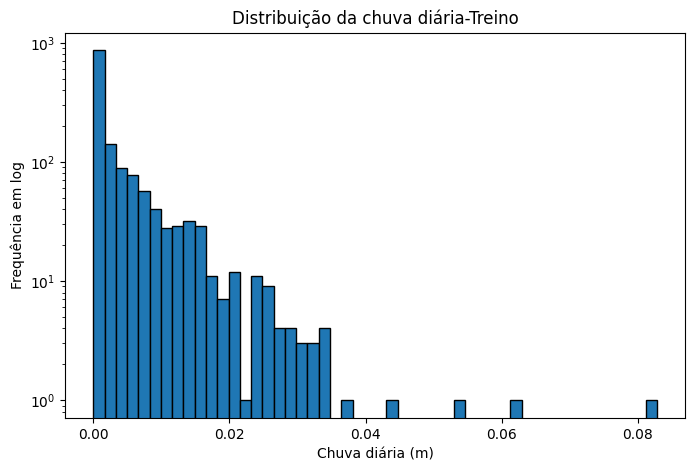

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_train['tp_mean'], bins=50, edgecolor='black')
plt.xlabel("Chuva diária (m)")
plt.ylabel("Frequência em log")
plt.title("Distribuição da chuva diária-Treino")
plt.yscale("log")  # opcional para mostrar melhor os valores raros
plt.show()

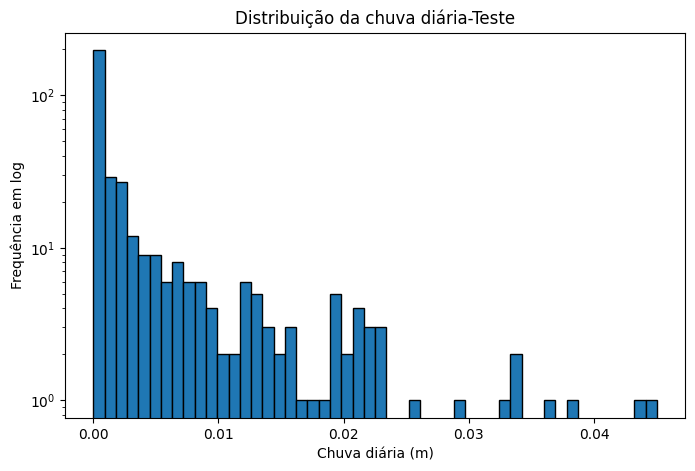

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_test['tp_mean'], bins=50, edgecolor='black')
plt.xlabel("Chuva diária (m)")
plt.ylabel("Frequência em log")
plt.title("Distribuição da chuva diária-Teste")
plt.yscale("log")  # opcional para mostrar melhor os valores raros
plt.show()

Estatísticas dos dados:
   - Dias chuvosos no treino: 304/360
   - Dias chuvosos no teste:  79/90

Dados para regressão (apenas dias chuvosos):
   - Treino: 304 amostras
   - Teste:  79 amostras

Melhores parâmetros encontrados:
OrderedDict({'max_depth': 10, 'max_features': 0.12391403148528458, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 150})
=== MÉTRICAS DE REGRESSÃO - RANDOM FOREST ===

--- CONJUNTO DE TREINO ---
MAE: 0.0036
RMSE: 0.0058
R²: 0.6508
Bias: 0.0001

--- CONJUNTO DE TESTE ---
MAE: 0.0065
RMSE: 0.0080
R²: -0.0864
Bias: 0.0015

--- COMPARAÇÃO ---
Diferença R² (Treino - Teste): 0.7372
Diferença RMSE (Treino - Teste): -0.0022
Diferença MAE (Treino - Teste): -0.0029

--- ANÁLISE DE OVERFITTING ---
⚠️  Possível overfitting: R² do treino muito maior que do teste


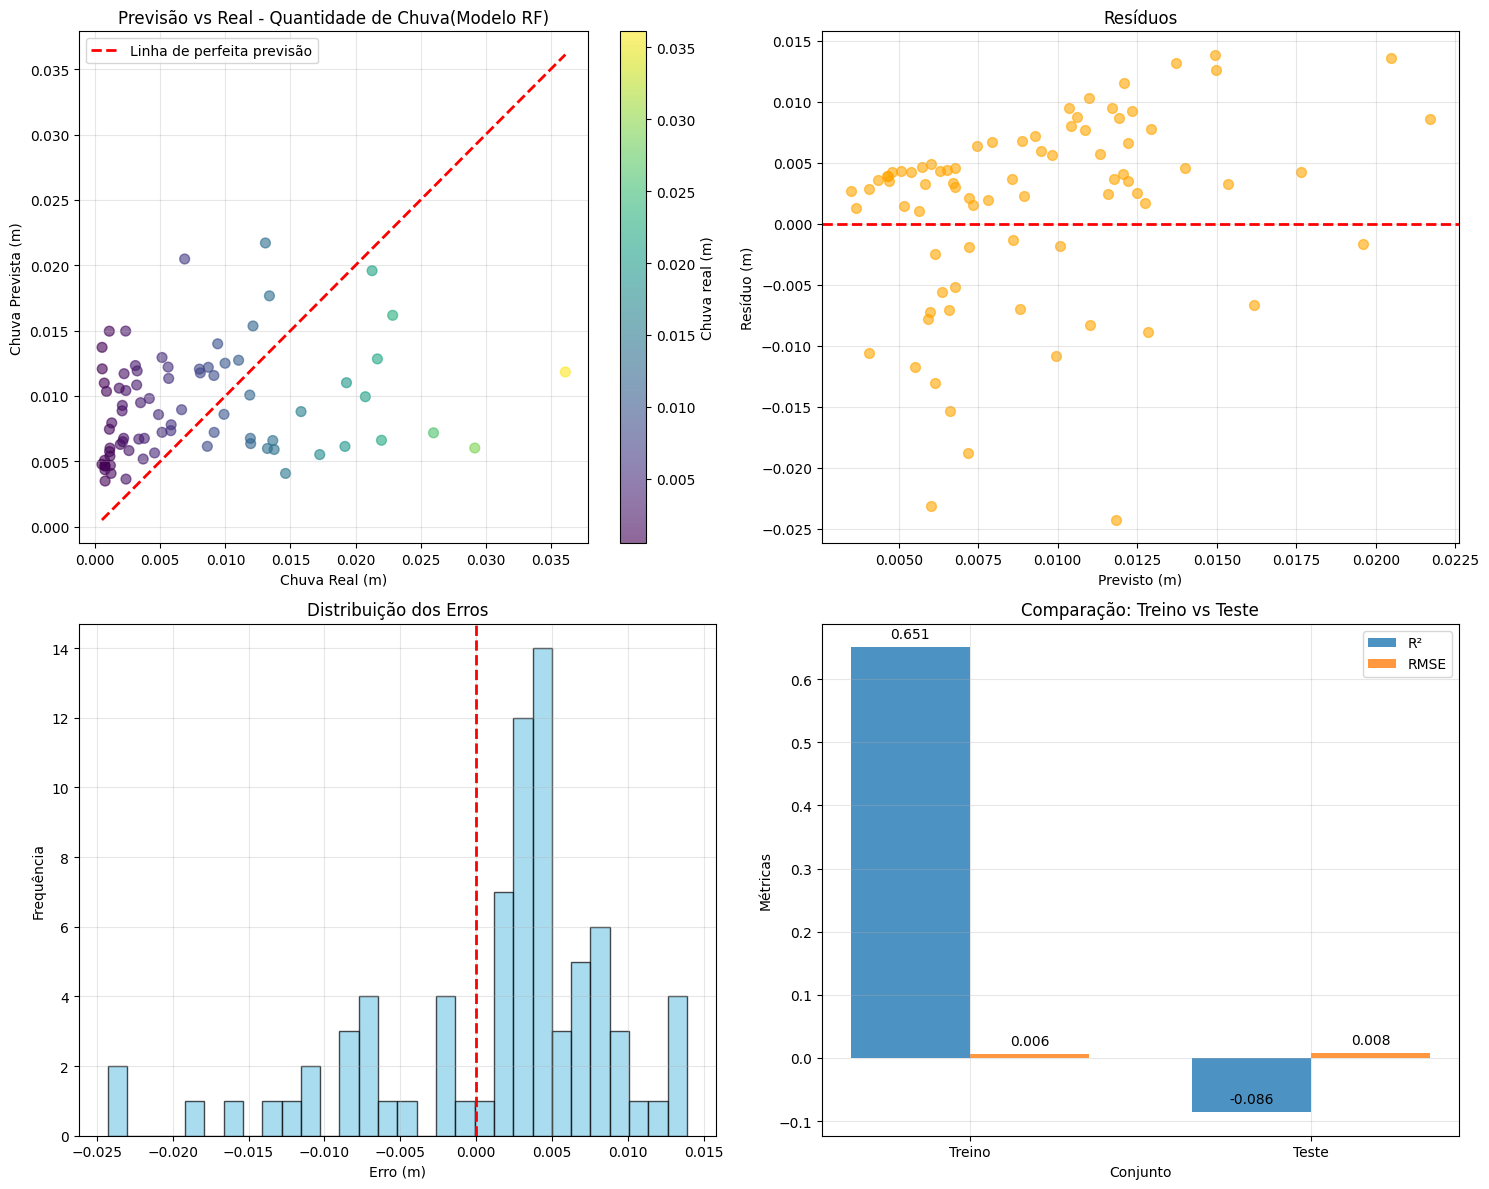

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real

y_train_original = y_train
y_test_original = y_test

limiar = 0.0005
mask_train_chuva = y_train_original > limiar
mask_test_chuva  = y_test_original > limiar

print("Estatísticas dos dados:")
print(f"   - Dias chuvosos no treino: {np.sum(mask_train_chuva)}/{len(mask_train_chuva)}")
print(f"   - Dias chuvosos no teste:  {np.sum(mask_test_chuva)}/{len(mask_test_chuva)}")

x_train_reg_chuva = X_train[mask_train_chuva.values]
y_train_reg_chuva = y_train_original[mask_train_chuva].values

x_test_reg_chuva  = X_test[mask_test_chuva.values]
y_test_reg_chuva  = y_test_original[mask_test_chuva].values

print(f"\nDados para regressão (apenas dias chuvosos):")
print(f"   - Treino: {len(x_train_reg_chuva)} amostras")
print(f"   - Teste:  {len(x_test_reg_chuva)} amostras")


search_spaces = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(5, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'max_features': Real(0.1, 1.0),
}

# Modelo base
rf_reg = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

bayes_reg = BayesSearchCV(
    estimator=rf_reg,
    search_spaces=search_spaces,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42,
)

bayes_reg.fit(x_train_reg_chuva, y_train_reg_chuva)

print("\nMelhores parâmetros encontrados:")
print(bayes_reg.best_params_)

# Modelo otimizado final
reg_model = bayes_reg.best_estimator_

# Fazer previsões para TESTE
y_pred_reg = reg_model.predict(x_test_reg_chuva)

# Fazer previsões para TREINO (CORREÇÃO: usar reg_model em vez de rf_reg)
y_pred_train_reg = reg_model.predict(x_train_reg_chuva)

# Para o conjunto de TESTE
mae_test = mean_absolute_error(y_test_reg_chuva, y_pred_reg)
rmse_test = np.sqrt(mean_squared_error(y_test_reg_chuva, y_pred_reg))
r2_test = r2_score(y_test_reg_chuva, y_pred_reg)
bias_test = np.mean(y_pred_reg - y_test_reg_chuva)

# Para o conjunto de TREINO
mae_train = mean_absolute_error(y_train_reg_chuva, y_pred_train_reg)
rmse_train = np.sqrt(mean_squared_error(y_train_reg_chuva, y_pred_train_reg))
r2_train = r2_score(y_train_reg_chuva, y_pred_train_reg)
bias_train = np.mean(y_pred_train_reg - y_train_reg_chuva)

# Calcular correlação apenas se houver variabilidade
if len(y_test_reg_chuva) > 1 and np.std(y_test_reg_chuva) > 0 and np.std(y_pred_reg) > 0:
    correlacao = np.corrcoef(y_test_reg_chuva, y_pred_reg)[0, 1]
else:
    correlacao = np.nan

# Exibindo os resultados
print("=== MÉTRICAS DE REGRESSÃO - RANDOM FOREST ===")
print("\n--- CONJUNTO DE TREINO ---")
print(f"MAE: {mae_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print(f"Bias: {bias_train:.4f}")

print("\n--- CONJUNTO DE TESTE ---")
print(f"MAE: {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²: {r2_test:.4f}")
print(f"Bias: {bias_test:.4f}")

# Comparação entre treino e teste
print("\n--- COMPARAÇÃO ---")
print(f"Diferença R² (Treino - Teste): {r2_train - r2_test:.4f}")
print(f"Diferença RMSE (Treino - Teste): {rmse_train - rmse_test:.4f}")
print(f"Diferença MAE (Treino - Teste): {mae_train - mae_test:.4f}")

# Análise de overfitting
print("\n--- ANÁLISE DE OVERFITTING ---")
if r2_train - r2_test > 0.1:
    print("⚠️  Possível overfitting: R² do treino muito maior que do teste")
elif r2_train - r2_test < 0.05:
    print("✅ Modelo generaliza bem: R² similar entre treino e teste")
else:
    print("🔍 Diferença moderada entre treino e teste")

# GRÁFICOS
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Dispersão: Previsão vs Real
scatter = axes[0,0].scatter(
    y_test_reg_chuva, y_pred_reg, alpha=0.6,
    c=y_test_reg_chuva, cmap='viridis', s=50
)
axes[0,0].plot(
    [y_test_reg_chuva.min(), y_test_reg_chuva.max()],
    [y_test_reg_chuva.min(), y_test_reg_chuva.max()],
    'r--', linewidth=2, label='Linha de perfeita previsão'
)
axes[0,0].set_xlabel("Chuva Real (m)")
axes[0,0].set_ylabel("Chuva Prevista (m)")
axes[0,0].set_title("Previsão vs Real - Quantidade de Chuva(Modelo RF)")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()
plt.colorbar(scatter, ax=axes[0,0], label='Chuva real (m)')

# 2. Resíduos
residuos = y_pred_reg - y_test_reg_chuva
axes[0,1].scatter(y_pred_reg, residuos, alpha=0.6, color='orange', s=50)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_xlabel("Previsto (m)")
axes[0,1].set_ylabel("Resíduo (m)")
axes[0,1].set_title("Resíduos")
axes[0,1].grid(True, alpha=0.3)

# 3. Histograma de erros
axes[1,0].hist(residuos, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_xlabel("Erro (m)")
axes[1,0].set_ylabel("Frequência")
axes[1,0].set_title("Distribuição dos Erros")
axes[1,0].grid(True, alpha=0.3)

# 4. Comparação Treino vs Teste (novo gráfico)
models = ['Treino', 'Teste']
r2_scores = [r2_train, r2_test]
rmse_scores = [rmse_train, rmse_test]

x_pos = np.arange(len(models))
width = 0.35

bars1 = axes[1,1].bar(x_pos - width/2, r2_scores, width, label='R²', alpha=0.8)
bars2 = axes[1,1].bar(x_pos + width/2, rmse_scores, width, label='RMSE', alpha=0.8)

axes[1,1].set_xlabel('Conjunto')
axes[1,1].set_ylabel('Métricas')
axes[1,1].set_title('Comparação: Treino vs Teste')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(models)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Adicionar valores nos gráficos de barras
for bar, value in zip(bars1, r2_scores):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{value:.3f}', ha='center', va='bottom')

for bar, value in zip(bars2, rmse_scores):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Estatísticas dos dados:
   - Dias chuvosos no treino: 825/1460
   - Dias chuvosos no teste:  194/365

Dados para regressão (apenas dias chuvosos):
   - Treino: 825 amostras
   - Teste:  194 amostras

🔍 Treinando HistGradientBoostingRegressor com BayesSearchCV...

Melhores parâmetros encontrados:
OrderedDict({'l2_regularization': 4.6823826922404495, 'learning_rate': 0.059043938117081855, 'max_depth': 3, 'max_iter': 239, 'min_samples_leaf': 80})

=== MÉTRICAS DE REGRESSÃO - HIST GRADIENT BOOSTING ===

--- CONJUNTO DE TREINO ---
MAE:  0.0044
RMSE: 0.0066
R²:   0.3042
Bias: -0.0001

--- CONJUNTO DE TESTE ---
MAE:  0.0062
RMSE: 0.0085
R²:   0.0633
Bias: -0.0003

Número real de iterações: 103


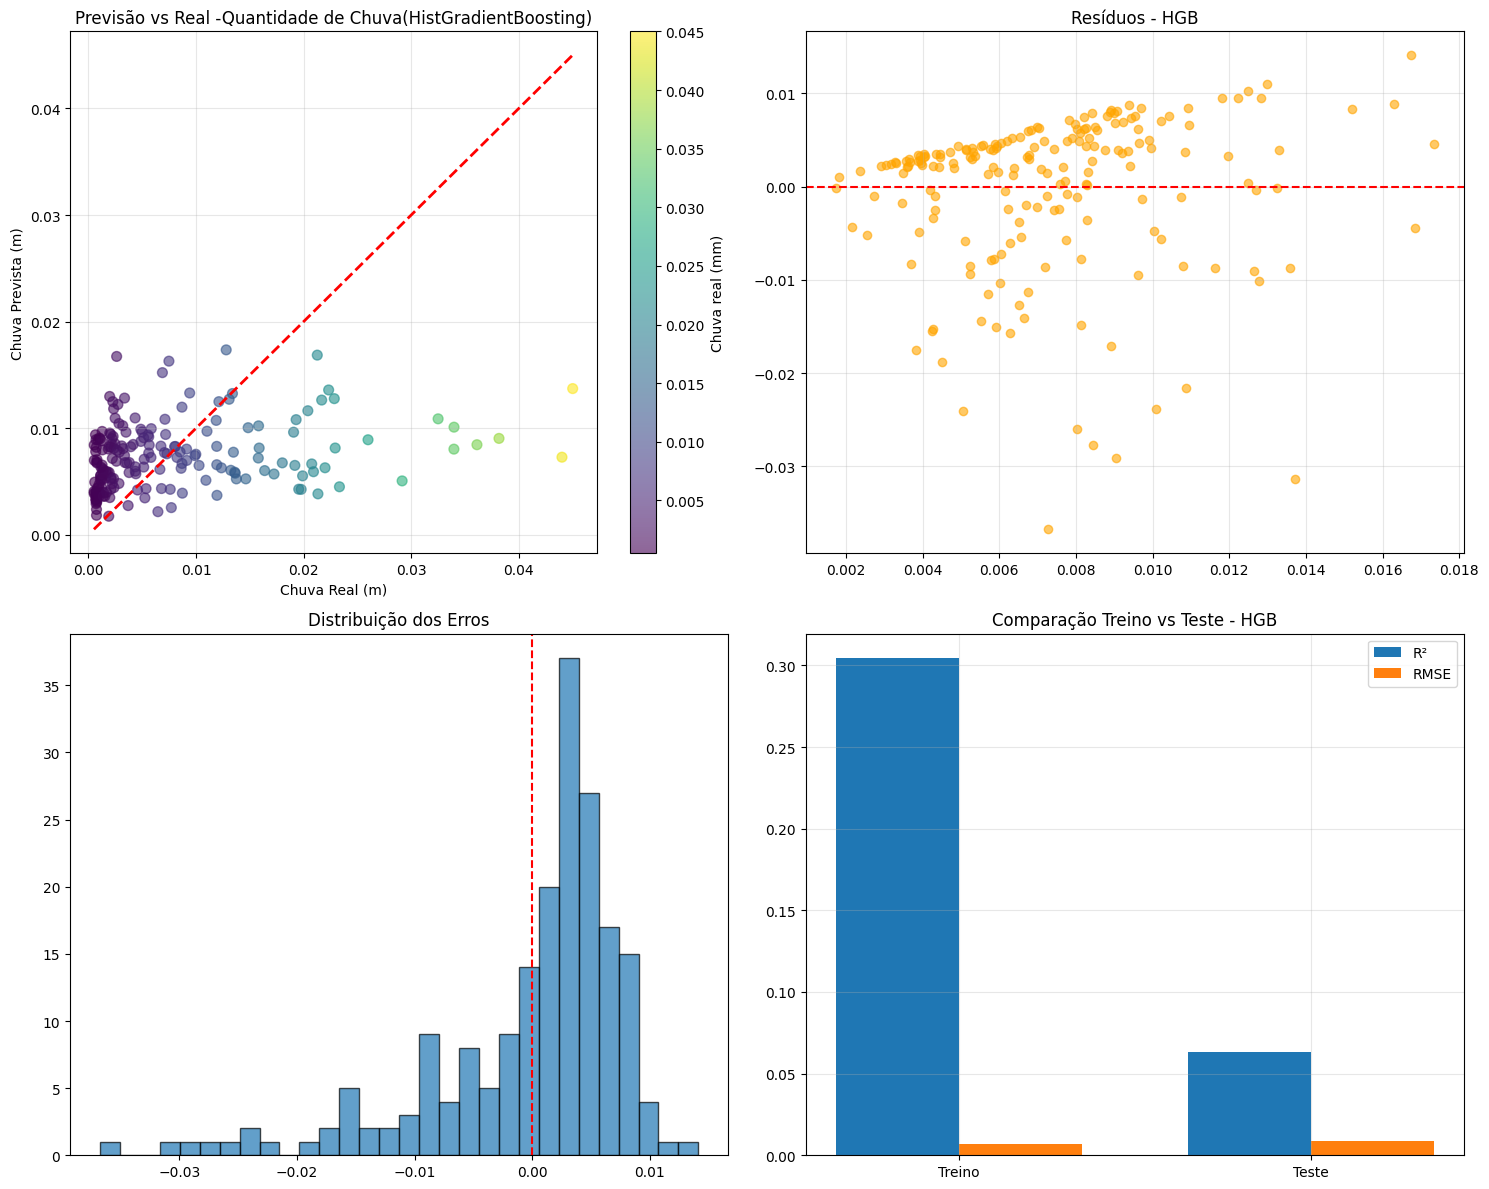

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real


y_train_original = y_train
y_test_original = y_test

limiar = 0.0005
mask_train_chuva = y_train_original > limiar
mask_test_chuva  = y_test_original > limiar

print("Estatísticas dos dados:")
print(f"   - Dias chuvosos no treino: {np.sum(mask_train_chuva)}/{len(mask_train_chuva)}")
print(f"   - Dias chuvosos no teste:  {np.sum(mask_test_chuva)}/{len(mask_test_chuva)}")

x_train_reg_chuva = X_train[mask_train_chuva.values]
y_train_reg_chuva = y_train_original[mask_train_chuva].values

x_test_reg_chuva  = X_test[mask_test_chuva.values]
y_test_reg_chuva  = y_test_original[mask_test_chuva].values

print(f"\nDados para regressão (apenas dias chuvosos):")
print(f"   - Treino: {len(x_train_reg_chuva)} amostras")
print(f"   - Teste:  {len(x_test_reg_chuva)} amostras")


# BayesSearchCV adaptado para HistGradientBoostingRegressor
search_spaces = {
    'learning_rate': Real(0.01, 0.5),
    'max_depth': Integer(2, 12),
    'max_iter': Integer(100, 2000),
    'min_samples_leaf': Integer(5, 80),
    'l2_regularization': Real(0.0, 5.0)
}

hgb_model = HistGradientBoostingRegressor(
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
    loss="squared_error"
)

bayes_reg = BayesSearchCV(
    estimator=hgb_model,
    search_spaces=search_spaces,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42
)

print("\n🔍 Treinando HistGradientBoostingRegressor com BayesSearchCV...")
bayes_reg.fit(x_train_reg_chuva, y_train_reg_chuva)

print("\nMelhores parâmetros encontrados:")
print(bayes_reg.best_params_)

reg_model = bayes_reg.best_estimator_

y_pred_train_reg = reg_model.predict(x_train_reg_chuva)
y_pred_reg       = reg_model.predict(x_test_reg_chuva)

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return mae, rmse, r2, bias

mae_train, rmse_train, r2_train, bias_train = compute_metrics(y_train_reg_chuva, y_pred_train_reg)
mae_test,  rmse_test,  r2_test,  bias_test  = compute_metrics(y_test_reg_chuva,  y_pred_reg)


print("\n=== MÉTRICAS DE REGRESSÃO - HIST GRADIENT BOOSTING ===")
print("\n--- CONJUNTO DE TREINO ---")
print(f"MAE:  {mae_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"R²:   {r2_train:.4f}")
print(f"Bias: {bias_train:.4f}")

print("\n--- CONJUNTO DE TESTE ---")
print(f"MAE:  {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²:   {r2_test:.4f}")
print(f"Bias: {bias_test:.4f}")

print("\nNúmero real de iterações:", reg_model.n_iter_)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1 — Previsão vs Real
scatter = axes[0,0].scatter(
    y_test_reg_chuva, y_pred_reg,
    alpha=0.6, c=y_test_reg_chuva, cmap='viridis', s=50
)
axes[0,0].plot(
    [y_test_reg_chuva.min(), y_test_reg_chuva.max()],
    [y_test_reg_chuva.min(), y_test_reg_chuva.max()],
    'r--', linewidth=2
)
axes[0,0].set_title("Previsão vs Real -Quantidade de Chuva(HistGradientBoosting)")
axes[0,0].set_xlabel("Chuva Real (m)")
axes[0,0].set_ylabel("Chuva Prevista (m)")
axes[0,0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0,0], label='Chuva real (mm)')

# 2 — Resíduos
residuos = y_pred_reg - y_test_reg_chuva
axes[0,1].scatter(y_pred_reg, residuos, alpha=0.6, color='orange')
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_title("Resíduos - HGB")
axes[0,1].grid(True, alpha=0.3)


# 3 — Histograma
axes[1,0].hist(residuos, bins=30, alpha=0.7, edgecolor='black')
axes[1,0].axvline(0, color='red', linestyle='--')
axes[1,0].set_title("Distribuição dos Erros")


# 4 — R2 & RMSE
models = ['Treino', 'Teste']
r2_scores = [r2_train, r2_test]
rmse_scores = [rmse_train, rmse_test]

x_pos = np.arange(len(models))
width = 0.35

axes[1,1].bar(x_pos - width/2, r2_scores, width, label='R²')
axes[1,1].bar(x_pos + width/2, rmse_scores, width, label='RMSE')
axes[1,1].set_title("Comparação Treino vs Teste - HGB")
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(models)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.1 MB/s eta 0:00:00


Estatísticas dos dados:
   - Dias chuvosos no treino: 825/825
   - Dias chuvosos no teste:  194/194

Dados para regressão (apenas dias chuvosos):
   - Treino: 825 amostras
   - Teste:  194 amostras

🔍 Treinando CatBoostRegressor com BayesSearchCV...

Melhores parâmetros encontrados:
OrderedDict({'depth': 6, 'iterations': 214, 'l2_leaf_reg': 0.07310201058203089, 'learning_rate': 0.011157966888137838, 'subsample': 0.8978334341407662})

=== MÉTRICAS DE REGRESSÃO - CATBOOST ===

--- CONJUNTO DE TREINO ---
MAE:  0.0043
RMSE: 0.0058
R²:   0.4713
Bias: -0.0000

--- CONJUNTO DE TESTE ---
MAE:  0.0064
RMSE: 0.0087
R²:   0.0283
Bias: 0.0000


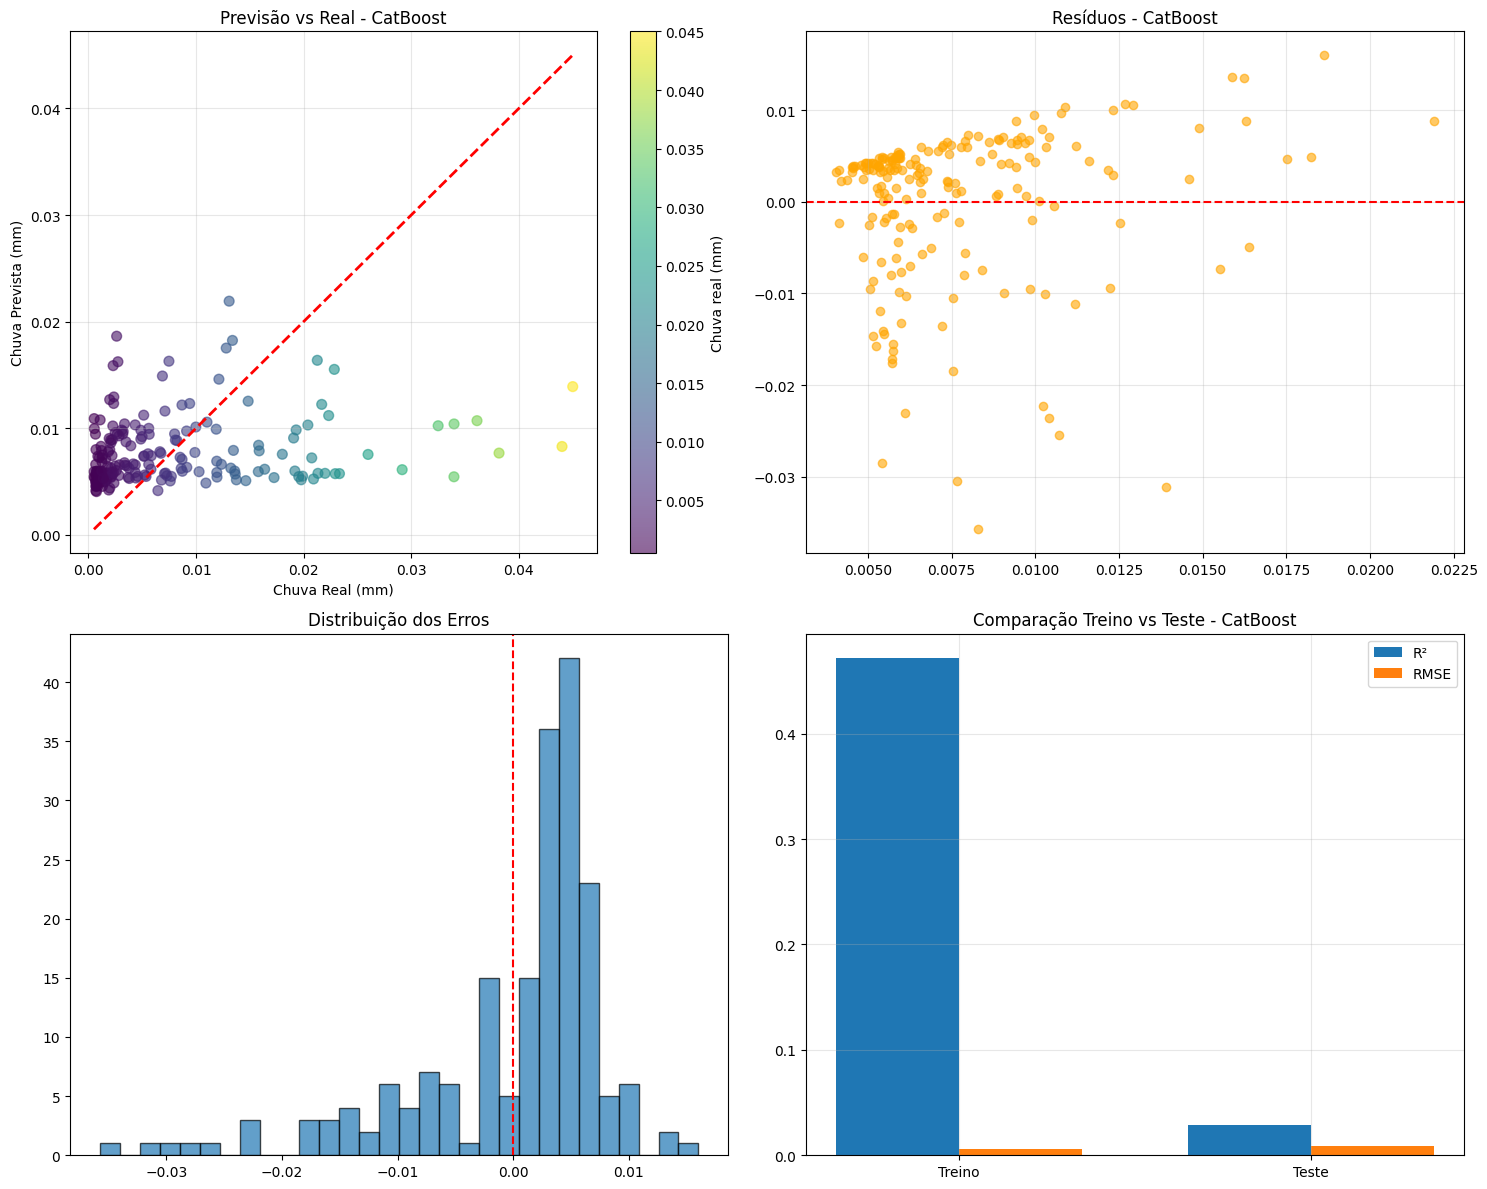

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. Prepara dados (mesma estrutura que você já usava)
# ==========================================================

y_train_original = y_train
y_test_original = y_test

limiar = 0.0005
mask_train_chuva = y_train_original > limiar
mask_test_chuva  = y_test_original  > limiar

print("Estatísticas dos dados:")
print(f"   - Dias chuvosos no treino: {np.sum(mask_train_chuva)}/{len(mask_train_chuva)}")
print(f"   - Dias chuvosos no teste:  {np.sum(mask_test_chuva)}/{len(mask_test_chuva)}")

x_train_reg_chuva = X_train[mask_train_chuva.values]
y_train_reg_chuva = y_train_original[mask_train_chuva].values

x_test_reg_chuva  = X_test[mask_test_chuva.values]
y_test_reg_chuva  = y_test_original[mask_test_chuva].values

print("\nDados para regressão (apenas dias chuvosos):")
print(f"   - Treino: {len(x_train_reg_chuva)} amostras")
print(f"   - Teste:  {len(x_test_reg_chuva)} amostras")

# ==========================================================
# 2. Define espaço de busca bayesiana
# ==========================================================

# CatBoost não usa max_depth diretamente — é max_depth dos trees.
# CatBoost também não usa min_split/min_leaf como scikit-learn.

search_spaces = {
    "iterations": Integer(200, 1200),
    "learning_rate": Real(0.01, 0.3),
    "depth": Integer(3, 10),
    "l2_leaf_reg": Real(1e-3, 10, prior='log-uniform'),
    "subsample": Real(0.5, 1.0),
}

base_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,  # evita criar diretórios
)

bayes_reg = BayesSearchCV(
    estimator=base_model,
    search_spaces=search_spaces,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42
)

# ==========================================================
# 3. Treino com CatBoost otimizado
# ==========================================================

print("\n🔍 Treinando CatBoostRegressor com BayesSearchCV...")
bayes_reg.fit(x_train_reg_chuva, y_train_reg_chuva)

print("\nMelhores parâmetros encontrados:")
print(bayes_reg.best_params_)

reg_model = bayes_reg.best_estimator_

# ==========================================================
# 4. Previsões
# ==========================================================

y_pred_train_reg = reg_model.predict(x_train_reg_chuva)
y_pred_reg        = reg_model.predict(x_test_reg_chuva)

# ==========================================================
# 5. Métricas
# ==========================================================

mae_train = mean_absolute_error(y_train_reg_chuva, y_pred_train_reg)
rmse_train = np.sqrt(mean_squared_error(y_train_reg_chuva, y_pred_train_reg))
r2_train = r2_score(y_train_reg_chuva, y_pred_train_reg)
bias_train = np.mean(y_pred_train_reg - y_train_reg_chuva)

mae_test = mean_absolute_error(y_test_reg_chuva, y_pred_reg)
rmse_test = np.sqrt(mean_squared_error(y_test_reg_chuva, y_pred_reg))
r2_test = r2_score(y_test_reg_chuva, y_pred_reg)
bias_test = np.mean(y_pred_reg - y_test_reg_chuva)

print("\n=== MÉTRICAS DE REGRESSÃO - CATBOOST ===")
print("\n--- CONJUNTO DE TREINO ---")
print(f"MAE:  {mae_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"R²:   {r2_train:.4f}")
print(f"Bias: {bias_train:.4f}")

print("\n--- CONJUNTO DE TESTE ---")
print(f"MAE:  {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R²:   {r2_test:.4f}")
print(f"Bias: {bias_test:.4f}")

# ==========================================================
# 6. Gráficos
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Dispersão
scatter = axes[0,0].scatter(
    y_test_reg_chuva, y_pred_reg,
    alpha=0.6, c=y_test_reg_chuva, cmap='viridis', s=50
)
axes[0,0].plot(
    [y_test_reg_chuva.min(), y_test_reg_chuva.max()],
    [y_test_reg_chuva.min(), y_test_reg_chuva.max()],
    'r--', linewidth=2
)
axes[0,0].set_title("Previsão vs Real - CatBoost")
axes[0,0].set_xlabel("Chuva Real (mm)")
axes[0,0].set_ylabel("Chuva Prevista (mm)")
axes[0,0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0,0], label='Chuva real (mm)')

# 2. Resíduos
residuos = y_pred_reg - y_test_reg_chuva
axes[0,1].scatter(y_pred_reg, residuos, alpha=0.6, color='orange')
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_title("Resíduos - CatBoost")
axes[0,1].grid(True, alpha=0.3)

# 3. Histograma dos erros
axes[1,0].hist(residuos, bins=30, alpha=0.7, edgecolor='black')
axes[1,0].axvline(0, color='red', linestyle='--')
axes[1,0].set_title("Distribuição dos Erros")

# 4. Comparação treino vs teste
models = ["Treino", "Teste"]
r2_scores = [r2_train, r2_test]
rmse_scores = [rmse_train, rmse_test]

x_pos = np.arange(len(models))
width = 0.35

axes[1,1].bar(x_pos - width/2, r2_scores, width, label='R²')
axes[1,1].bar(x_pos + width/2, rmse_scores, width, label='RMSE')
axes[1,1].set_title("Comparação Treino vs Teste - CatBoost")
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(models)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 5.9 MB/s eta 0:00:00


Estatísticas dos dados:
   - Dias chuvosos no treino: 825/825
   - Dias chuvosos no teste:  194/194

Dados para regressão (apenas dias chuvosos):
   - Treino: 825 amostras
   - Teste:  194 amostras

Estatísticas da precipitação:
   - Treino: min=0.0005, max=0.0828, mean=0.0069
   - Teste:  min=0.0005, max=0.0450, mean=0.0077

🔍 Treinando HistGradientBoostingRegressor...
Melhores parâmetros HGBR:
OrderedDict({'l2_regularization': 4.6823826922404495, 'learning_rate': 0.059043938117081855, 'max_depth': 3, 'max_iter': 239, 'min_samples_leaf': 80})

🔍 Treinando RandomForestRegressor...
Melhores parâmetros RF:
OrderedDict({'max_depth': 14, 'max_features': 0.21060449289860195, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 269})

🔍 Treinando CatBoostRegressor...
Melhores parâmetros CatBoost:
OrderedDict({'depth': 6, 'iterations': 214, 'l2_leaf_reg': 0.07310201058203089, 'learning_rate': 0.011157966888137838, 'subsample': 0.8978334341407662})


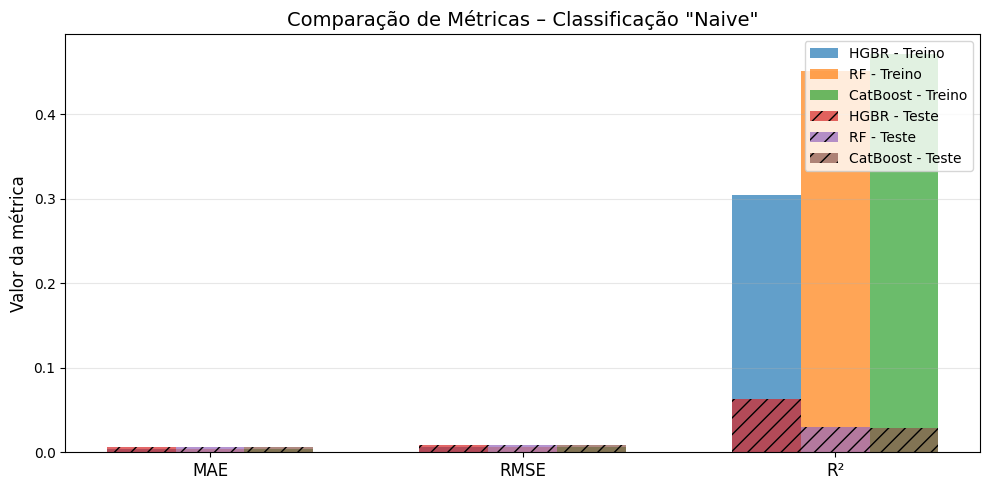

{'HGBR': (0.004430103836396086, np.float64(0.006600356338957092), 0.3042413699830522), 'RF': (0.0038727099602893843, np.float64(0.0058626343082397335), 0.45107950452110956), 'CatBoost': (0.004278816294899103, np.float64(0.005753726911219248), 0.4712841541069501)}
{'HGBR': (0.006190623054084145, np.float64(0.008510867802318007), 0.06329969272780456), 'RF': (0.00647754577610819, np.float64(0.008659962583073886), 0.030193692618572965), 'CatBoost': (0.006437714895136019, np.float64(0.008668405241365055), 0.028301828923449568)}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor

from skopt import BayesSearchCV
from skopt.space import Real, Integer

from catboost import CatBoostRegressor


# ============================================================
# 1) Filtrar apenas dias chuvosos
# ============================================================

y_train_original = y_train
y_test_original  = y_test

limiar = 0.0005
mask_train_chuva = y_train_original > limiar
mask_test_chuva  = y_test_original > limiar

print("Estatísticas dos dados:")
print(f"   - Dias chuvosos no treino: {np.sum(mask_train_chuva)}/{len(mask_train_chuva)}")
print(f"   - Dias chuvosos no teste:  {np.sum(mask_test_chuva)}/{len(mask_test_chuva)}")

# Filtrar X e Y
x_train_reg_chuva = X_train[mask_train_chuva.values]
y_train_reg_chuva = y_train_original[mask_train_chuva].values

x_test_reg_chuva  = X_test[mask_test_chuva.values]
y_test_reg_chuva  = y_test_original[mask_test_chuva].values

print("\nDados para regressão (apenas dias chuvosos):")
print(f"   - Treino: {len(x_train_reg_chuva)} amostras")
print(f"   - Teste:  {len(x_test_reg_chuva)} amostras")

print("\nEstatísticas da precipitação:")
print(f"   - Treino: min={np.min(y_train_reg_chuva):.4f}, max={np.max(y_train_reg_chuva):.4f}, mean={np.mean(y_train_reg_chuva):.4f}")
print(f"   - Teste:  min={np.min(y_test_reg_chuva):.4f}, max={np.max(y_test_reg_chuva):.4f}, mean={np.mean(y_test_reg_chuva):.4f}")



# ============================================================
# 2) Bayesian Search – HIST GRADIENT BOOSTING REGRESSOR
# ============================================================

search_spaces_hgb = {
    'learning_rate': Real(0.01, 0.5),
    'max_depth': Integer(2, 12),
    'max_iter': Integer(100, 2000),
    'min_samples_leaf': Integer(5, 80),
    'l2_regularization': Real(0.0, 5.0)
}

hgb_model = HistGradientBoostingRegressor(
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
    loss="squared_error"
)

bayes_hgb = BayesSearchCV(
    estimator=hgb_model,
    search_spaces=search_spaces_hgb,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42
)

print("\n🔍 Treinando HistGradientBoostingRegressor...")
bayes_hgb.fit(x_train_reg_chuva, y_train_reg_chuva)
best_hgb = bayes_hgb.best_estimator_

print("Melhores parâmetros HGBR:")
print(bayes_hgb.best_params_)



# ============================================================
# 3) Bayesian Search – RANDOM FOREST REGRESSOR
# ============================================================

search_spaces_rf = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(5, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'max_features': Real(0.1, 1.0),
}

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

bayes_rf = BayesSearchCV(
    estimator=rf_model,
    search_spaces=search_spaces_rf,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42
)

print("\n🔍 Treinando RandomForestRegressor...")
bayes_rf.fit(x_train_reg_chuva, y_train_reg_chuva)
best_rf = bayes_rf.best_estimator_

print("Melhores parâmetros RF:")
print(bayes_rf.best_params_)



# ============================================================
# 4) Bayesian Search – CATBOOST REGRESSOR
# ============================================================

search_spaces_cat = {
    "iterations": Integer(200, 1200),
    "learning_rate": Real(0.01, 0.3),
    "depth": Integer(3, 10),
    "l2_leaf_reg": Real(1e-3, 10, prior='log-uniform'),
    "subsample": Real(0.5, 1.0),
}

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

bayes_cat = BayesSearchCV(
    estimator=cat_model,
    search_spaces=search_spaces_cat,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42
)

print("\n🔍 Treinando CatBoostRegressor...")
bayes_cat.fit(x_train_reg_chuva, y_train_reg_chuva)
best_cat = bayes_cat.best_estimator_

print("Melhores parâmetros CatBoost:")
print(bayes_cat.best_params_)

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2


# ============================================================
# 6) Calcular métricas de TREINO e TESTE
# ============================================================

models = {
    "HGBR": best_hgb,
    "RF": best_rf,
    "CatBoost": best_cat
}

train_metrics = {}
test_metrics  = {}

for name, model in models.items():
    y_pred_train = model.predict(x_train_reg_chuva)
    y_pred_test  = model.predict(x_test_reg_chuva)

    train_metrics[name] = compute_metrics(y_train_reg_chuva, y_pred_train)
    test_metrics[name]  = compute_metrics(y_test_reg_chuva,  y_pred_test)



# ============================================================
# 7) Gráfico comparativo — estilo mais limpo e organizado
# ============================================================

metric_names = ["MAE", "RMSE", "R²"]
x = np.arange(len(metric_names))
width = 0.22

plt.figure(figsize=(10, 5))

# ---- Barras de treino ----
plt.bar(x - width,      train_metrics["HGBR"], width, alpha=0.7, label="HGBR - Treino")
plt.bar(x,              train_metrics["RF"],   width, alpha=0.7, label="RF - Treino")
plt.bar(x + width,      train_metrics["CatBoost"], width, alpha=0.7, label="CatBoost - Treino")

# ---- Barras de teste ----
plt.bar(x - width,      test_metrics["HGBR"], width, alpha=0.7, hatch="//", label="HGBR - Teste")
plt.bar(x,              test_metrics["RF"],   width, alpha=0.7, hatch="//", label="RF - Teste")
plt.bar(x + width,      test_metrics["CatBoost"], width, alpha=0.7, hatch="//", label="CatBoost - Teste")

plt.xticks(x, metric_names, fontsize=12)
plt.ylabel("Valor da métrica", fontsize=12)
plt.title("Comparação de Métricas – Classificação \"Naive\"", fontsize=14)

plt.grid(axis='y', alpha=0.3)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

print(train_metrics)
print(test_metrics )

